# Tutorial 17 — bcc iron with spin–orbit coupling: spin texture

The waw-native reimagining of Wannier90 tutorial 17. Ferromagnetic bcc **iron** with full **spin–orbit coupling** (noncollinear DFT): 28 bands disentangle into **18 spinor MLWFs** (each a 2-component spinor). Because SOC mixes the spin channels, the band energies alone don't tell you the spin — we interpolate a per-band **spin expectation** $\langle S_z \rangle$ from the `.spn` Pauli matrices between Bloch states (`pw2wannier90 write_spn`), giving a **spin-coloured band structure**.

Fully waw-native: converged noncollinear+SOC QE, waw's own spinor `.nnkp`, `pw2wannier90` SCDM, waw disentanglement, and `waw.analysis.spin_texture`. No `wannier90.x`.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged noncollinear+SOC DFT and Wannierisation
PseudoDojo **fully-relativistic** Fe pseudo, `ecutwfc = 60` Ry, 16×16×16 SCF (magnetisation ≈ 2.3 μB along $z$, $E_F$ ≈ 17.6 eV). The Wannier overlaps and the `.spn` spin operator are built on a 4×4×4 mesh. (The SCF is the slow step, a few minutes.)

In [2]:
from ase.build import bulk
import torch
from waw.interfaces.ase.structure import real_lattice, recip_lattice, band_path_segments

atoms = bulk('Fe', 'bcc', a=2.8699)          # 5.4235 bohr
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'fe'

# noncollinear + spin-orbit; PseudoDojo fully-relativistic Fe pseudo
SOC = dict(noncolin=True, lspinorb=True)
SOC['starting_magnetization(1)'] = 0.4
SOC.update(occupations='smearing', smearing='cold', degauss=0.02)

# scf (16^3) -> waw .nnkp (spinor) -> nscf (4^3, 36 bands) -> pw2wannier90 SCDM
# 8 semicore 3s3p spinor bands are excluded; 28 -> 18 spinor MLWFs.
ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'fe',
    ecutwfc=60, scf_kpts=(16, 16, 16), nbnd=36, num_wann=18,
    exclude_bands=list(range(1, 9)),
    scdm_entanglement='erfc', scdm_mu=25.0, scdm_sigma=5.0,
    system_extra=SOC, pseudopotentials={'Fe': 'Fe-sp_r.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, write_spn=True,
    rerun_scf=False,          # reuse a completed SCF in runs/fe/ if present
)

result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=18,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8),
    n_restarts=2, dis_n_iter=1000, n_iter=3000, verbose=False,
)
E_FERMI = ov['fermi_energy']                 # eV, read from the SCF by qe.py
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2  '
      f'(18 spinor MLWFs from 28 bands; W90 tut17/18 4x4x4: ~9.17); '
      f'E_F = {E_FERMI:.3f} eV')

# ASE's standard bcc high-symmetry path, as parse_kpoint_path-style segments
KPATH = band_path_segments(atoms)
REAL = real_lattice(atoms)
RECIP = recip_lattice(atoms)

Omega_I = 9.3225 Ang^2  (18 spinor MLWFs from 28 bands; W90 tut17/18 4x4x4: ~9.17); E_F = 17.630 eV


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

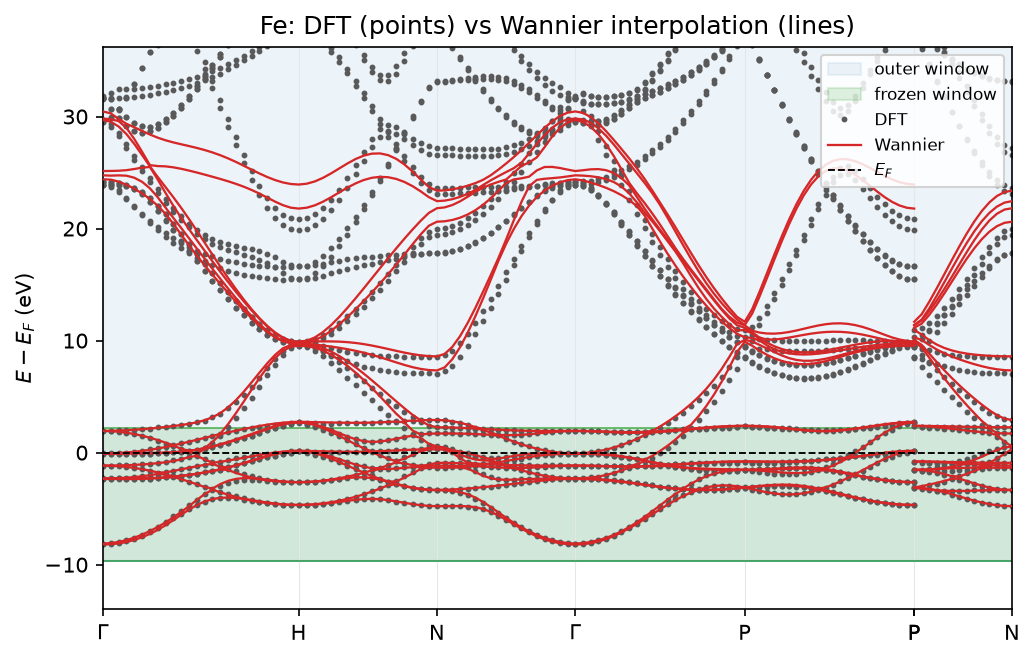

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 629 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'fe', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Fe: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(8.0, 19.8), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. Spin operator $S(R)$ and the spin-coloured bands
The `.spn` file holds $\langle\psi_{nk}|\sigma_i|\psi_{mk}\rangle$ between the ab-initio Bloch states. We rotate it into the Wannier gauge (the same $W = V\,U$ that builds $H(R)$), Fourier-transform to $S(R)$, and interpolate $\langle n(k)|S_z|n(k)\rangle$ along the k-path.

In [4]:
from waw.analysis.spin_texture import spin_operator_r, spin_colored_bands

W = torch.bmm(result.dis.V, result.spread.U_final)      # full spinor gauge
SS_R = spin_operator_r(W, ov['spn'], result.wdata.kpts, MP_GRID, REAL)

scb = spin_colored_bands(result.hr, SS_R, KPATH, RECIP, n_points=120,
                         axis=(0.0, 0.0, 1.0))
bands = scb.bands.bands * HARTREE_TO_EV        # (nk, nw) eV
spin = scb.spin                                # (nk, nw), <S_z> in [-1, 1]
print('S_z range:', float(spin.min()), '..', float(spin.max()))

S_z range: -1.007945795932947 .. 1.001147431247558


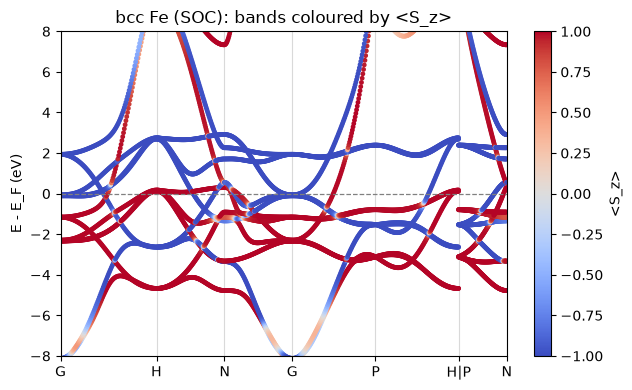

In [5]:
dist = scb.bands.kpath.dists
series = BandSeries(bands=bands - E_FERMI, color_by=spin, vmin=-1, vmax=1)
plot_bands(dist, scb.bands.kpath.tick_dists, scb.bands.kpath.tick_labels, series,
           figsize=(6.5, 4), ref_line=0.0, ref_color='0.5', ylim=(-8, 8),
           ylabel='E - E_F (eV)', colorbar_label='<S_z>',
           title='bcc Fe (SOC): bands coloured by <S_z>')
plt.tight_layout(); plt.show()

**Takeaway.** The 18-spinor-MLWF model reproduces the exchange-split bands of ferromagnetic Fe and their spin character: majority (blue, $\langle S_z\rangle < 0$ for magnetisation along $+z$) and minority (red) bands, with spin-orbit coupling mixing them where they cross. All from waw — DFT, disentanglement, and spin interpolation.